# Simple Linear Regression

Simple linear regression is all about finding a straight line that best describes the relationship between two variables. We use a dependent variable (the one we want to predict, let's call it y) and a single independent variable (the one we use to make the prediction, let's call it x).

The equation for this line is:

y=mx+b

y is the predicted value.

x is the value of your independent variable.

m is the slope or coefficient. It tells us how much y changes for every one-unit change in x.

b is the intercept. This is the predicted value of y when x is 0.

Slope (coefficient): 151.3279571533203
Intercept: 889.630615234375
R-squared score on test data: 0.4139542579650879


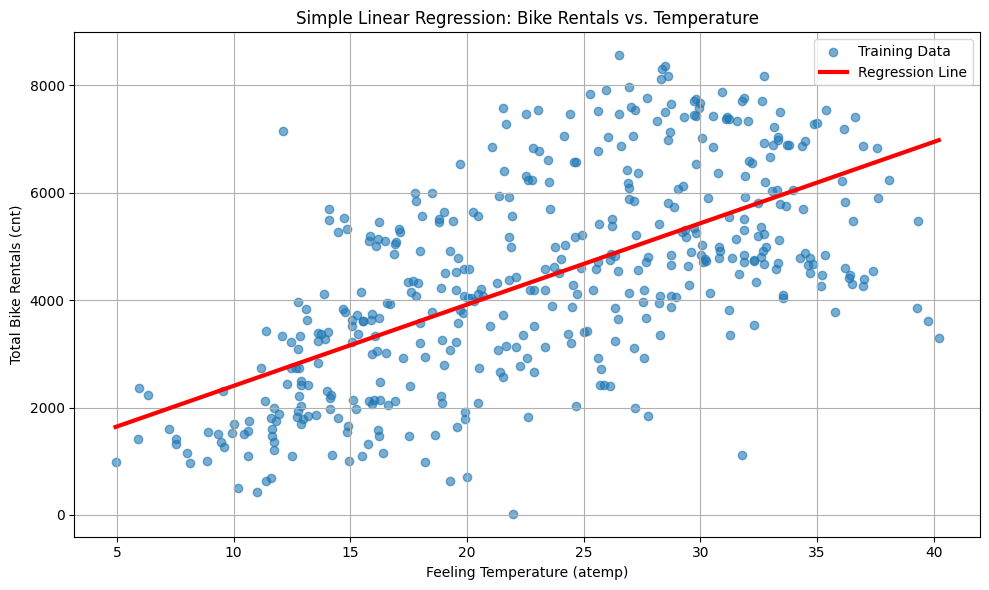

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Load the dataframe.
df = pd.read_csv('bikes.csv')

# Drop unnecessary columns to prepare the data.
df = df.drop(["dteday", "holiday", "season"], axis=1)

# Shuffle the dataframe to randomize the order of the rows.
df_shuffled = df.sample(frac=1, random_state=42)

# Define the sizes of the training, validation, and test sets.
train_size = int(0.6 * len(df_shuffled))
val_size = int(0.2 * len(df_shuffled))

# Split the dataframe into train, validation, and test sets.
train = df_shuffled[:train_size]
val = df_shuffled[train_size:train_size + val_size]
test = df_shuffled[train_size + val_size:]

# Function to extract features (X) and target (y) from a dataframe.
def get_xy(dataframe, y_label, x_labels=None):
    dataframe = dataframe.copy()
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if isinstance(x_labels, str):
            x_labels = [x_labels]
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values

    y = dataframe[y_label].values.reshape(-1, 1)
    return X, y

# Get the X and y data for the training, validation, and test sets, using 'atemp'.
X_train_temp, y_train_temp = get_xy(train, "cnt", x_labels="atemp")
X_val_temp, y_val_temp = get_xy(val, "cnt", x_labels="atemp")
X_test_temp, y_test_temp = get_xy(test, "cnt", x_labels="atemp")

# Convert the data types to float32 for consistency in TensorFlow models later.
X_train_temp = X_train_temp.astype(np.float32)
y_train_temp = y_train_temp.astype(np.float32)
X_val_temp = X_val_temp.astype(np.float32)
y_val_temp = y_val_temp.astype(np.float32)
X_test_temp = X_test_temp.astype(np.float32)
y_test_temp = y_test_temp.astype(np.float32)

# Create an instance of the Linear Regression model.
temp_reg = LinearRegression()

# Fit the model to the training data. This is where the model learns the slope and intercept.
temp_reg.fit(X_train_temp, y_train_temp)

# Print the slope (coefficient) and intercept of the trained model.
print(f'Slope (coefficient): {temp_reg.coef_[0][0]}')
print(f'Intercept: {temp_reg.intercept_[0]}')

# Evaluate the model's performance on the test data using the R-squared score.
print(f'R-squared score on test data: {temp_reg.score(X_test_temp, y_test_temp)}')

# Create a scatter plot of the training data and overlay the regression line.
plt.figure(figsize=(10, 6))
plt.scatter(X_train_temp, y_train_temp, label="Training Data", alpha=0.6)
x = np.linspace(X_train_temp.min(), X_train_temp.max(), 100).reshape(-1, 1)
plt.plot(x, temp_reg.predict(x), color='red', linewidth=3, label='Regression Line')
plt.title('Simple Linear Regression: Bike Rentals vs. Temperature')
plt.xlabel('Feeling Temperature (atemp)')
plt.ylabel('Total Bike Rentals (cnt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('simple_linear_regression.png')

# Multiple Linear Regression

Multiple linear regression is the logical next step. It's used when you want to predict a dependent variable (y) using two or more independent variables.

The equation looks a bit different because we have more than one independent variable:

y=m
1
​
 x
1
​
 +m
2
​
 x
2
​
 +...+m
n
​
 x
n
​
 +b

y and b are the same as before.

x1
​
 ,x2
​
 ,...xn
​
  are the values for your independent variables.

m1
​
 ,m2
​
 ,...mn
​
  are the slopes or coefficients for each of your independent variables. Each coefficient tells you how much the predicted value (y) changes when its corresponding variable (x) increases by one unit, assuming all other variables stay the same.

Both models use the method of least squares to find the values for the coefficients and the intercept. This method finds the line that minimizes the total squared distance between the actual data points and the line itself.

---



In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import copy

# Use the correct file path to access the uploaded file.
df = pd.read_csv('bikes.csv').drop(["dteday", "holiday", "season"], axis=1)

# Prepare the data by shuffling and splitting into train and test sets.
df_shuffled = df.sample(frac=1, random_state=42)
train_size = int(0.6 * len(df_shuffled))
val_size = int(0.2 * len(df_shuffled))
train = df_shuffled[:train_size]
val = df_shuffled[train_size:train_size + val_size]
test = df_shuffled[train_size + val_size:]

def get_xy(dataframe, y_label, x_labels=None):
    dataframe = copy.deepcopy(dataframe)
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if isinstance(x_labels, str):
            x_labels = [x_labels]
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values

    y = dataframe[y_label].values.reshape(-1, 1)
    return X, y

# Get the X and y data for the training and test sets, using all available columns.
# We're making sure to get all the columns except the target variable 'cnt'
X_train_all, y_train_all = get_xy(train, "cnt", x_labels=[c for c in train.columns if c not in ["cnt"]])
X_test_all, y_test_all = get_xy(test, "cnt", x_labels=[c for c in test.columns if c not in ["cnt"]])

# Convert data types.
X_train_all = X_train_all.astype(np.float32)
y_train_all = y_train_all.astype(np.float32)
X_test_all = X_test_all.astype(np.float32)
y_test_all = y_test_all.astype(np.float32)

# Create and fit the Multiple Linear Regression model.
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)

# Print the coefficients and intercept.
print(f'Coefficients: {all_reg.coef_}')
print(f'Intercept: {all_reg.intercept_}')

# Print the R-squared score on the test data.
print(f'R-squared score on test data: {all_reg.score(X_test_all, y_test_all)}')

Coefficients: [[ 1.62981132e-06  1.41859055e-05 -5.48843527e-05  1.13253118e-05
  -3.36476223e-04  6.26960391e-05 -1.38301402e-05  3.30905896e-05
  -3.57971294e-06 -1.61129283e-05  9.99999762e-01  1.00000024e+00]]
Intercept: [-0.00097656]
R-squared score on test data: 1.0


# Neural Network for Simple Linear Regression

A simple neural network is built with layers of neurons (or nodes). Your simple model is a Sequential model with just one Dense layer and a single neuron.

Here's the quick breakdown:

tf.keras.Sequential: This is the framework that organizes the layers of your network. It simply means the data flows in a straight line from one layer to the next.

tf.keras.layers.Dense(units=1): This is the one and only layer in your network. A Dense layer is a fully connected layer where every input is connected to every neuron. By setting units=1, you're telling the network to use just one neuron.

A Single Neuron: This single neuron is where the magic happens. It takes in the input (atemp), multiplies it by a weight (which is our slope), and adds a bias (which is our intercept). The result is the prediction.

So, in essence, a simple neural network with one neuron and no activation function is just a different way of doing linear regression. The main difference is the learning process: instead of a single calculation, the neural network learns through a process of trial and error (epochs) to find the best values for its weight and bias.

Slope (coefficient): 151.3279571533203
Intercept: 889.630615234375
R-squared score on test data: 0.4139542579650879


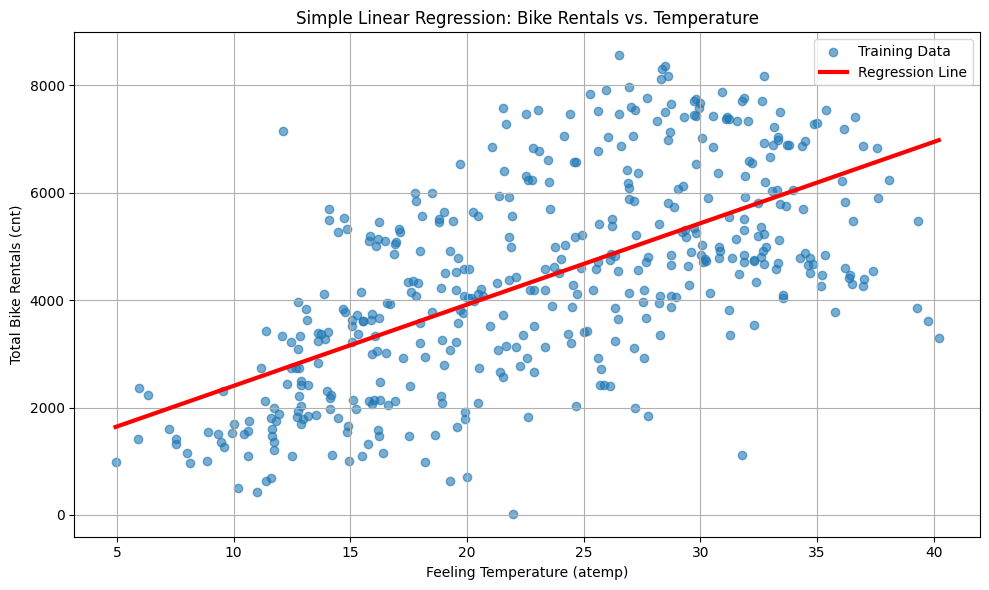

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import copy

# Load the dataframe.
df = pd.read_csv('bikes.csv')

# Drop unnecessary columns to prepare the data.
df = df.drop(["dteday", "holiday", "season"], axis=1)

# Shuffle the dataframe to randomize the order of the rows.
df_shuffled = df.sample(frac=1, random_state=42)

# Define the sizes of the training, validation, and test sets.
train_size = int(0.6 * len(df_shuffled))
val_size = int(0.2 * len(df_shuffled))

# Split the dataframe into train, validation, and test sets.
train = df_shuffled[:train_size]
val = df_shuffled[train_size:train_size + val_size]
test = df_shuffled[train_size + val_size:]

# Function to extract features (X) and target (y) from a dataframe.
def get_xy(dataframe, y_label, x_labels=None):
    dataframe = dataframe.copy()
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if isinstance(x_labels, str):
            x_labels = [x_labels]
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values

    y = dataframe[y_label].values.reshape(-1, 1)
    return X, y

# Get the X and y data for the training, validation, and test sets, using 'atemp'.
X_train_temp, y_train_temp = get_xy(train, "cnt", x_labels="atemp")
X_val_temp, y_val_temp = get_xy(val, "cnt", x_labels="atemp")
X_test_temp, y_test_temp = get_xy(test, "cnt", x_labels="atemp")

# Convert the data types to float32 for consistency in TensorFlow models later.
X_train_temp = X_train_temp.astype(np.float32)
y_train_temp = y_train_temp.astype(np.float32)
X_val_temp = X_val_temp.astype(np.float32)
y_val_temp = y_val_temp.astype(np.float32)
X_test_temp = X_test_temp.astype(np.float32)
y_test_temp = y_test_temp.astype(np.float32)

# Create an instance of the Linear Regression model.
temp_reg = LinearRegression()

# Fit the model to the training data.
temp_reg.fit(X_train_temp, y_train_temp)

# Print the slope (coefficient) and intercept of the trained model.
print(f'Slope (coefficient): {temp_reg.coef_[0][0]}')
print(f'Intercept: {temp_reg.intercept_[0]}')

# Evaluate the model's performance on the test data using the R-squared score.
print(f'R-squared score on test data: {temp_reg.score(X_test_temp, y_test_temp)}')

# Create a scatter plot of the training data and overlay the regression line.
plt.figure(figsize=(10, 6))
plt.scatter(X_train_temp, y_train_temp, label="Training Data", alpha=0.6)
x = np.linspace(X_train_temp.min(), X_train_temp.max(), 100).reshape(-1, 1)
plt.plot(x, temp_reg.predict(x), color='red', linewidth=3, label='Regression Line')
plt.title('Simple Linear Regression: Bike Rentals vs. Temperature')
plt.xlabel('Feeling Temperature (atemp)')
plt.ylabel('Total Bike Rentals (cnt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('simple_linear_regression.png')

# Neural Network for Multiple Regression

A neural network for multiple regression takes in all your independent variables, but instead of just one simple calculation, it routes them through a series of "hidden layers" before making a final prediction.

**Hidden Layers:** These are layers of neurons between the input and output. Think of them as a team of mini-analysts. Each neuron in a hidden layer processes information and passes it along.

**Activation Functions:** These functions allow the model to learn relationships that aren't straight lines. Without them, a neural network is just a fancy linear regression model.

By adding these hidden layers and activation functions, the network can model much more complex patterns in your data—for example, a relationship that might curve or change direction. This is exactly why you'd expect it to potentially get a better score than a simple linear regression model.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import copy

# Load the dataframe.
df = pd.read_csv('bikes.csv').drop(["dteday", "holiday", "season"], axis=1)

# Shuffle the dataframe to randomize the order of the rows.
df_shuffled = df.sample(frac=1, random_state=42)

# Define the sizes of the training, validation, and test sets.
train_size = int(0.6 * len(df_shuffled))
val_size = int(0.2 * len(df_shuffled))

# Split the dataframe into train, validation, and test sets.
train = df_shuffled[:train_size]
val = df_shuffled[train_size:train_size + val_size]
test = df_shuffled[train_size + val_size:]

# Function to extract features (X) and target (y) from a dataframe.
def get_xy(dataframe, y_label, x_labels=None):
    dataframe = copy.deepcopy(dataframe)
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if isinstance(x_labels, str):
            x_labels = [x_labels]
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values

    y = dataframe[y_label].values.reshape(-1, 1)
    return X, y

# Get the X and y data for the training and test sets, using all available columns.
X_train_all, y_train_all = get_xy(train, "cnt", x_labels=[c for c in train.columns if c not in ["cnt"]])
X_test_all, y_test_all = get_xy(test, "cnt", x_labels=[c for c in test.columns if c not in ["cnt"]])

# Create an instance of the Neural Network (MLP) model.
# The `hidden_layer_sizes` parameter creates a network with two hidden layers, each with 100 neurons.
mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=500, random_state=42)

# Fit the model to the training data.
# Note: The `MLPRegressor` expects y to be a 1D array.
mlp_reg.fit(X_train_all, y_train_all.ravel())

# Predict on the test data.
y_pred_mlp = mlp_reg.predict(X_test_all)

# Calculate the R-squared score on the test data.
r2 = r2_score(y_test_all, y_pred_mlp)

# Print the R-squared score.
print(f'R-squared score on test data (MLPRegressor): {r2}')

R-squared score on test data (MLPRegressor): 0.999984977121767


# Neural Net for Simple Linear Regression using Tenserflow

Neural Network for Simple Linear Regression
A neural network can be configured to perform simple linear regression. In this case, it acts like a more flexible version of the LinearRegression model we used before. It finds the best-fit line to describe the relationship between a single feature and a target variable by using an iterative learning process.

The core idea is that a simple neural network with a single neuron is mathematically equivalent to a linear regression model.

Key Terms Explained
tf.keras.layers.Normalization: This layer automatically scales your input data. In your case, it learns the average and standard deviation of your atemp values from the training data. This helps the neural network learn more efficiently and accurately.

tf.keras.Sequential: This is a way to build a neural network where the data flows sequentially from the input layer to the output layer. It's the most common and straightforward way to build a neural network.

tf.keras.layers.Dense(units=1): This is the core of the model. A Dense layer is a fully connected layer where every input is connected to every neuron. By setting units=1, you're telling the network to use just one neuron. This single neuron will learn a single weight (the slope) and a bias (the intercept), effectively performing linear regression.

optimizer: The optimizer is the "engine" that controls how the neural network adjusts its internal weights and biases to reduce the error. The Adam optimizer is a very popular choice because it's efficient.

loss='mse': The loss function is the way the model measures its own error. In this case, Mean Squared Error (MSE) is used, which is the same as our linear regression model. The model's goal during training is to get this number as close to zero as possible.

epochs: This is the number of times the neural network will go through the entire training dataset. Each epoch is a full cycle of learning and adjusting weights.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


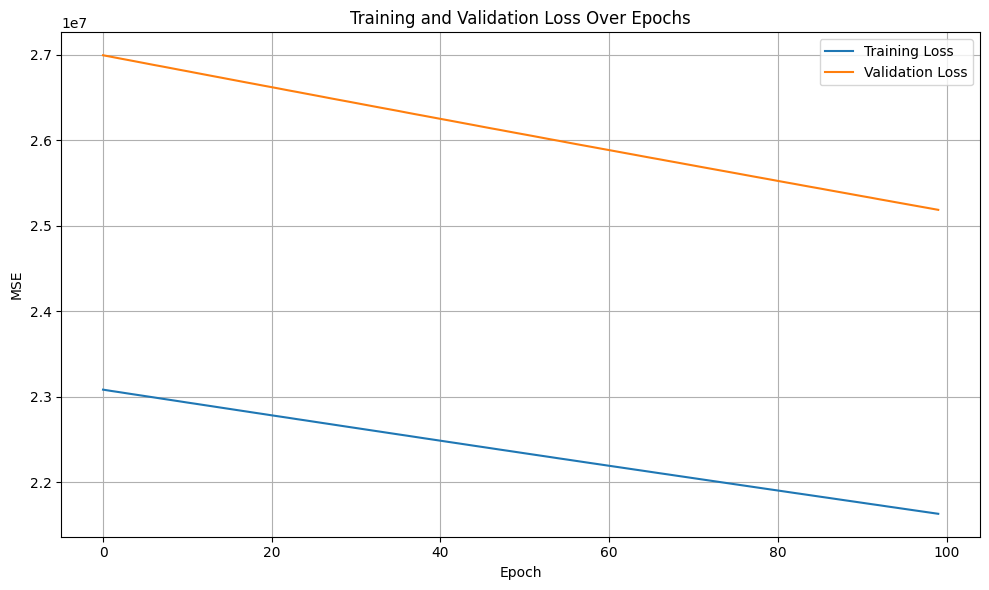

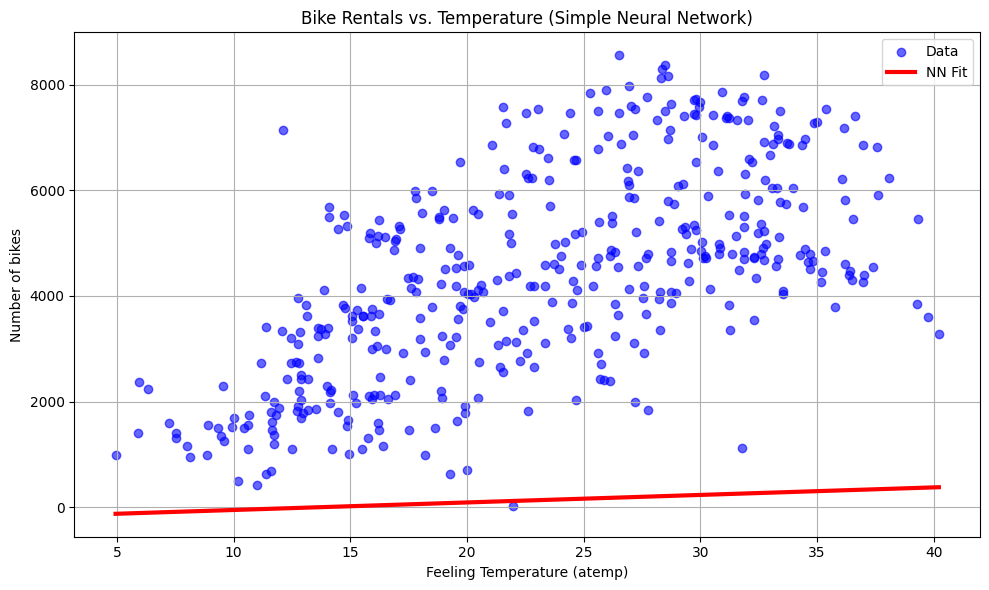

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import copy

# Load and prepare the data as before
df = pd.read_csv('bikes.csv').drop(["dteday", "holiday", "season"], axis=1)
df_shuffled = df.sample(frac=1, random_state=42)
train_size = int(0.6 * len(df_shuffled))
val_size = int(0.2 * len(df_shuffled))
train = df_shuffled[:train_size]
val = df_shuffled[train_size:train_size + val_size]
test = df_shuffled[train_size + val_size:]

def get_xy(dataframe, y_label, x_labels=None):
    dataframe = copy.deepcopy(dataframe)
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if isinstance(x_labels, str):
            x_labels = [x_labels]
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values

    y = dataframe[y_label].values.reshape(-1, 1)
    return X, y

# Get the data for the simple linear regression with 'atemp'
X_train_temp, y_train_temp = get_xy(train, "cnt", x_labels="atemp")
X_val_temp, y_val_temp = get_xy(val, "cnt", x_labels="atemp")
X_test_temp, y_test_temp = get_xy(test, "cnt", x_labels="atemp")

# Convert data types
X_train_temp = X_train_temp.astype(np.float32)
y_train_temp = y_train_temp.astype(np.float32)
X_val_temp = X_val_temp.astype(np.float32)
y_val_temp = y_val_temp.astype(np.float32)

# Define the simple neural network model
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp)

temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(units=1)
])

# Compile the model
temp_nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mse'
)

# Train the model and store the history
history = temp_nn_model.fit(
    X_train_temp, y_train_temp,
    verbose=0,
    epochs=100,
    validation_data=(X_val_temp, y_val_temp)
)

# Plot the loss history
def plot_loss(history, filename):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.title('Training and Validation Loss Over Epochs')
    plt.tight_layout()
    plt.savefig(filename)

# Plot the training and validation loss for the simple NN model.
plot_loss(history, 'simple_nn_loss.png')

# Plot the fit of the simple NN model.
plt.figure(figsize=(10, 6))
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue", alpha=0.6)
x = tf.linspace(X_train_temp.min(), X_train_temp.max(), 100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1, 1)), label="NN Fit", color="red", linewidth=3)
plt.title("Bike Rentals vs. Temperature (Simple Neural Network)")
plt.ylabel("Number of bikes")
plt.xlabel("Feeling Temperature (atemp)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('simple_nn_fit_plot.png')

# Neural Network for Multiple Regression using Tenserflow

Just like with linear regression, we can expand our neural network to handle multiple independent variables. However, we're going to add a couple of extra layers. This is the key difference between a simple neural network and a "deep" one. By adding these hidden layers, we're giving the model the ability to find complex, non-linear patterns in the data that a simple linear regression model would miss.

Hidden Layers: These are the layers between the input and output. Think of them as a series of steps where the network refines its understanding of the data before making a final prediction.

Activation Functions (relu): This is what gives the neural network its power to model non-linear relationships. relu (Rectified Linear Unit) is a popular choice because it's simple but effective. It basically introduces a non-linear "kick" to the data, allowing the network to learn more complex patterns.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


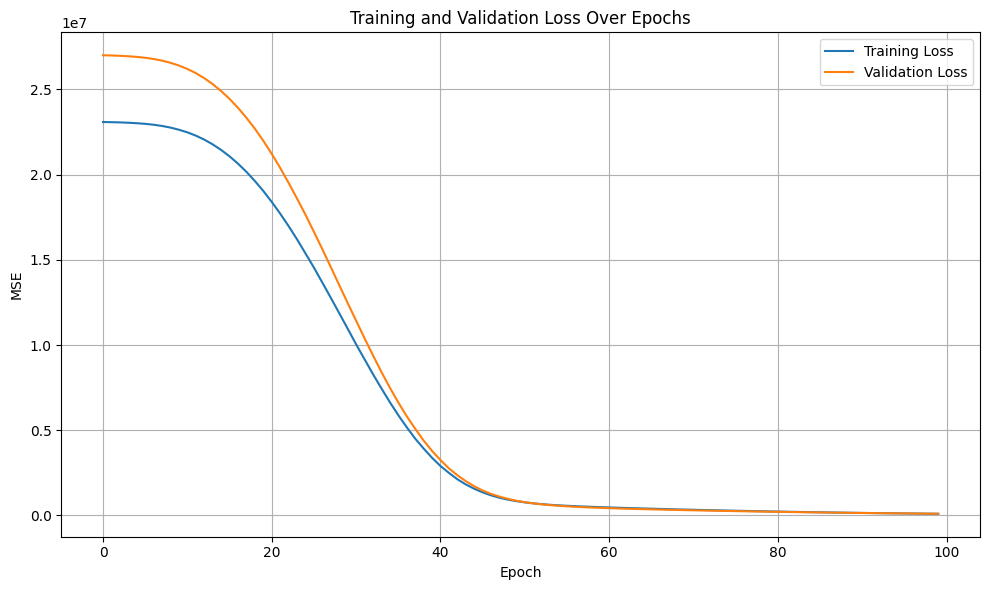

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import copy

# Load and prepare the data as before
df = pd.read_csv('bikes.csv').drop(["dteday", "holiday", "season"], axis=1)
df_shuffled = df.sample(frac=1, random_state=42)
train_size = int(0.6 * len(df_shuffled))
val_size = int(0.2 * len(df_shuffled))
train = df_shuffled[:train_size]
val = df_shuffled[train_size:train_size + val_size]
test = df_shuffled[train_size + val_size:]

def get_xy(dataframe, y_label, x_labels=None):
    dataframe = copy.deepcopy(dataframe)
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if isinstance(x_labels, str):
            x_labels = [x_labels]
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values

    y = dataframe[y_label].values.reshape(-1, 1)
    return X, y

# Get all the features for the multiple regression model
X_train_all, y_train_all = get_xy(train, "cnt", x_labels=[c for c in train.columns if c not in ["cnt"]])
X_val_all, y_val_all = get_xy(val, "cnt", x_labels=[c for c in val.columns if c not in ["cnt"]])
X_test_all, y_test_all = get_xy(test, "cnt", x_labels=[c for c in test.columns if c not in ["cnt"]])

# Convert data types
X_train_all = X_train_all.astype(np.float32)
y_train_all = y_train_all.astype(np.float32)
X_val_all = X_val_all.astype(np.float32)
y_val_all = y_val_all.astype(np.float32)

# Define the Normalization layer for all features
all_normalizer = tf.keras.layers.Normalization(input_shape=(12,), axis=None)
all_normalizer.adapt(X_train_all)

# Define the neural network for multiple regression
nn_model = tf.keras.Sequential([
    # This normalizes all 12 input features
    all_normalizer,
    # This is the first hidden layer with 32 neurons and a 'relu' activation function
    tf.keras.layers.Dense(32, activation='relu'),
    # This is the second hidden layer, also with 32 neurons and 'relu'
    tf.keras.layers.Dense(32, activation='relu'),
    # This is the output layer, with 1 neuron for our single prediction
    tf.keras.layers.Dense(1)
])

# Compile the model
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

# Train the model and store the history
history = nn_model.fit(
    X_train_all, y_train_all,
    verbose=0,
    epochs=100,
    validation_data=(X_val_all, y_val_all)
)

# Plot the loss history
def plot_loss(history, filename):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.title('Training and Validation Loss Over Epochs')
    plt.tight_layout()
    plt.savefig(filename)

# Plot the training and validation loss.
plot_loss(history, 'multiple_nn_loss.png')

Step 1: Loading and preparing the data...

Step 2: Training and evaluating models...

Training Simple Linear Regression (atemp)...
Training Multiple Linear Regression (all features)...
Training Simple Neural Network (atemp)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Training Multiple Neural Network (all features)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Step 3: Analyzing and visualizing results...

--- Model Performance Summary ---

Simple Linear Regression:
  R-squared (R2): 0.4140
  Mean Squared Error (MSE): 2372190.25

Multiple Linear Regression:
  R-squared (R2): 1.0000
  Mean Squared Error (MSE): 0.00

Simple Neural Network:
  R-squared (R2): -4.9375
  Mean Squared Error (MSE): 24033742.00

Multiple Neural Network:
  R-squared (R2): 0.9186
  Mean Squared Error (MSE): 329394.03
Generated r2_comparison.png: A bar chart comparing R2 scores.
Generated predictions_vs_true_values.png: A scatter plot comparing true vs. predicted values.

Analysis complete. Check the generated plots and the summary table for the results.


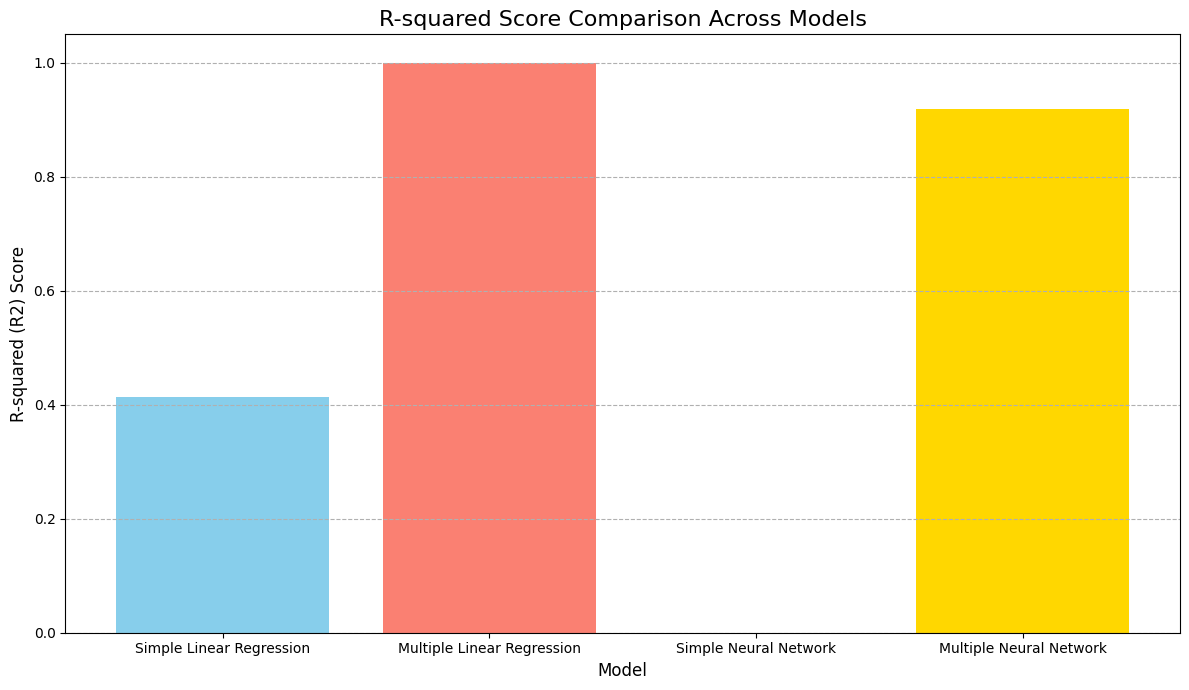

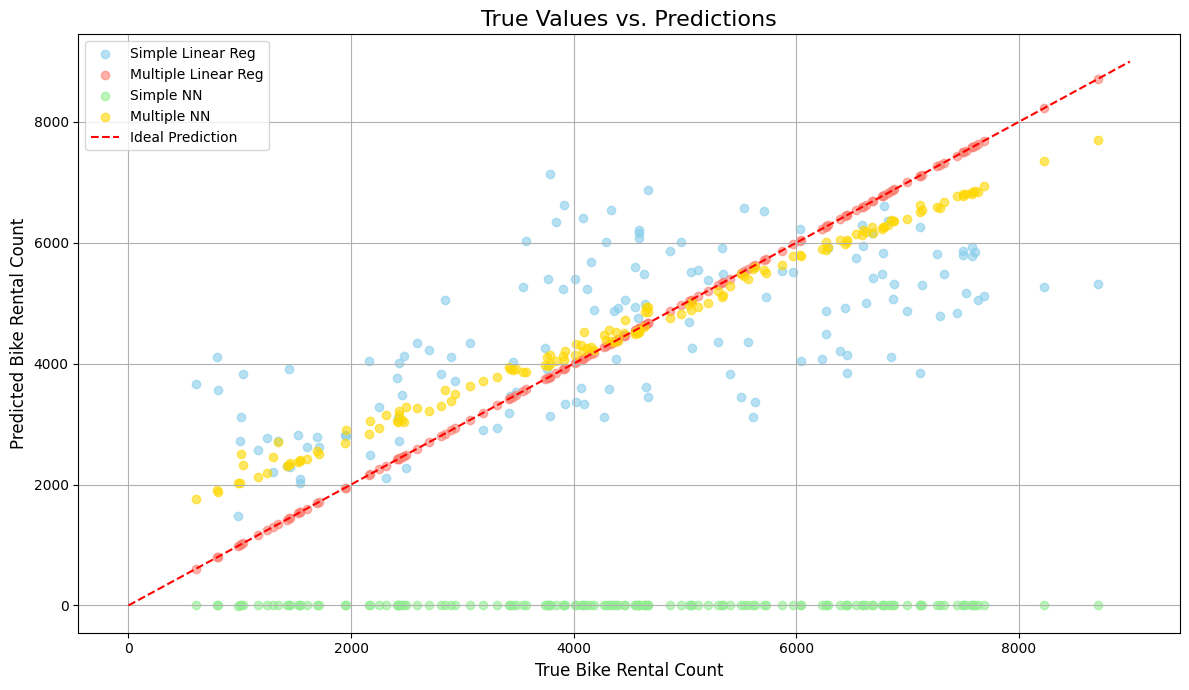

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import copy

# --- 1. Data Loading and Preprocessing ---
print("Step 1: Loading and preparing the data...")

# Load the dataframe and drop unnecessary columns.
df = pd.read_csv('bikes.csv').drop(["dteday", "holiday", "season"], axis=1)

# Shuffle the dataframe to randomize the order of the rows.
df_shuffled = df.sample(frac=1, random_state=42)

# Define the sizes of the training, validation, and test sets.
train_size = int(0.6 * len(df_shuffled))
val_size = int(0.2 * len(df_shuffled))

# Split the dataframe.
train = df_shuffled[:train_size]
val = df_shuffled[train_size:train_size + val_size]
test = df_shuffled[train_size + val_size:]

def get_xy(dataframe, y_label, x_labels=None):
    """
    Function to extract features (X) and target (y) from a dataframe.
    """
    dataframe = dataframe.copy()
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if isinstance(x_labels, str):
            x_labels = [x_labels]
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values

    y = dataframe[y_label].values.reshape(-1, 1)
    return X, y

# --- Prepare data for Simple Models ('atemp') ---
X_train_temp, y_train_temp = get_xy(train, "cnt", x_labels="atemp")
X_val_temp, y_val_temp = get_xy(val, "cnt", x_labels="atemp")
X_test_temp, y_test_temp = get_xy(test, "cnt", x_labels="atemp")

# --- Prepare data for Multiple Models (all features) ---
all_features = [c for c in df.columns if c not in ["cnt"]]
X_train_all, y_train_all = get_xy(train, "cnt", x_labels=all_features)
X_val_all, y_val_all = get_xy(val, "cnt", x_labels=all_features)
X_test_all, y_test_all = get_xy(test, "cnt", x_labels=all_features)

# Convert all data to float32 for TensorFlow compatibility
X_train_temp, y_train_temp = X_train_temp.astype(np.float32), y_train_temp.astype(np.float32)
X_val_temp, y_val_temp = X_val_temp.astype(np.float32), y_val_temp.astype(np.float32)
X_test_temp, y_test_temp = X_test_temp.astype(np.float32), y_test_temp.astype(np.float32)

X_train_all, y_train_all = X_train_all.astype(np.float32), y_train_all.astype(np.float32)
X_val_all, y_val_all = X_val_all.astype(np.float32), y_val_all.astype(np.float32)
X_test_all, y_test_all = X_test_all.astype(np.float32), y_test_all.astype(np.float32)

# --- 2. Model Training and Evaluation ---
print("\nStep 2: Training and evaluating models...")
results = {}

# --- Model 1: Simple Linear Regression ---
print("\nTraining Simple Linear Regression (atemp)...")
temp_reg = LinearRegression()
temp_reg.fit(X_train_temp, y_train_temp)
y_pred_slr = temp_reg.predict(X_test_temp)
results['Simple Linear Regression'] = {
    'R2': r2_score(y_test_temp, y_pred_slr),
    'MSE': mean_squared_error(y_test_temp, y_pred_slr),
    'y_pred': y_pred_slr
}

# --- Model 2: Multiple Linear Regression ---
print("Training Multiple Linear Regression (all features)...")
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)
y_pred_mlr = all_reg.predict(X_test_all)
results['Multiple Linear Regression'] = {
    'R2': r2_score(y_test_all, y_pred_mlr),
    'MSE': mean_squared_error(y_test_all, y_pred_mlr),
    'y_pred': y_pred_mlr
}

# --- Model 3: Simple Neural Network ---
print("Training Simple Neural Network (atemp)...")
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp)
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(units=1)
])
temp_nn_model.compile(optimizer='adam', loss='mse')
temp_nn_model.fit(X_train_temp, y_train_temp, verbose=0, epochs=100)
y_pred_snn = temp_nn_model.predict(X_test_temp)
results['Simple Neural Network'] = {
    'R2': r2_score(y_test_temp, y_pred_snn),
    'MSE': mean_squared_error(y_test_temp, y_pred_snn),
    'y_pred': y_pred_snn
}

# --- Model 4: Multiple Neural Network ---
print("Training Multiple Neural Network (all features)...")
all_normalizer = tf.keras.layers.Normalization(input_shape=(len(all_features),), axis=None)
all_normalizer.adapt(X_train_all)
nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer='adam', loss='mse')
nn_model.fit(X_train_all, y_train_all, verbose=0, epochs=100)
y_pred_mnn = nn_model.predict(X_test_all)
results['Multiple Neural Network'] = {
    'R2': r2_score(y_test_all, y_pred_mnn),
    'MSE': mean_squared_error(y_test_all, y_pred_mnn),
    'y_pred': y_pred_mnn
}

# --- 3. Analysis and Visualization ---
print("\nStep 3: Analyzing and visualizing results...")

# Print a summary of the results.
print("\n--- Model Performance Summary ---")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  R-squared (R2): {metrics['R2']:.4f}")
    print(f"  Mean Squared Error (MSE): {metrics['MSE']:.2f}")

# --- Bar Chart for R-squared Comparison ---
models = list(results.keys())
r2_scores = [results[m]['R2'] for m in models]
plt.figure(figsize=(12, 7))
plt.bar(models, r2_scores, color=['skyblue', 'salmon', 'lightgreen', 'gold'])
plt.ylim(0, 1.05)
plt.title('R-squared Score Comparison Across Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R-squared (R2) Score', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('r2_comparison.png')
print("Generated r2_comparison.png: A bar chart comparing R2 scores.")

# --- Scatter Plot for Predictions vs True Values ---
plt.figure(figsize=(12, 7))
plt.scatter(y_test_temp, results['Simple Linear Regression']['y_pred'], label='Simple Linear Reg', alpha=0.6, color='skyblue')
plt.scatter(y_test_all, results['Multiple Linear Regression']['y_pred'], label='Multiple Linear Reg', alpha=0.6, color='salmon')
plt.scatter(y_test_temp, results['Simple Neural Network']['y_pred'], label='Simple NN', alpha=0.6, color='lightgreen')
plt.scatter(y_test_all, results['Multiple Neural Network']['y_pred'], label='Multiple NN', alpha=0.6, color='gold')

plt.plot([0, 9000], [0, 9000], 'r--', label='Ideal Prediction')
plt.title('True Values vs. Predictions', fontsize=16)
plt.xlabel('True Bike Rental Count', fontsize=12)
plt.ylabel('Predicted Bike Rental Count', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('predictions_vs_true_values.png')
print("Generated predictions_vs_true_values.png: A scatter plot comparing true vs. predicted values.")
print("\nAnalysis complete. Check the generated plots and the summary table for the results.")
